# 10_01 Population Dynamics: A General Framework

## 1. Introduction

Population dynamics is the study of how populations change through time and the mechanisms responsible for those changes. Classical population ecology typically examines quantities such as population size, density, age structure, survivorship, birth rates, death rates, immigration, emigration, and interactions between species. These properties are often analyzed statistically using observations collected over both space and time.

Traditional ecological models usually focus on a specific process. For example, exponential growth models describe unrestricted population growth, logistic models introduce resource limitations, while predator-prey and competition models describe interactions between multiple species. Although each model is useful within its intended domain, they are generally developed independently and emphasize only a subset of the processes occurring within an ecological system.

The objective of this notebook is different. Rather than constructing another specialized population model, we instead develop a **general systems framework** for describing population dynamics. In this framework, populations, environmental variables, and species interactions are treated as components of a single coupled dynamical system.

The resulting equations are intentionally general. Individual ecological models may then be obtained by introducing assumptions, simplifying relationships, or eliminating variables appropriate for a particular ecological system.

Throughout this notebook we will progressively develop three increasingly general models:

1. A single population interacting with an abiotic environment.
2. Two interacting populations.
3. A community consisting of an arbitrary number of interacting populations.

The purpose is not to replace existing ecological models, but rather to provide a unified mathematical framework within which many of those models may be viewed as special cases.

## 2. A Systems Perspective

Before constructing mathematical equations, it is useful to view population dynamics from the perspective of systems theory.

A population does not exist in isolation. Instead, it continuously exchanges energy, matter, and information with its surrounding environment. Environmental conditions influence the growth of the population, while the population simultaneously modifies the environment through resource consumption, waste production, habitat modification, and numerous other ecological processes.

Rather than viewing these processes as a simple sequence of causes and effects, it is more useful to regard the population and its environment as two coupled dynamical systems. At any instant in time, the state of the population depends upon both the current population and the current environment, while the state of the environment likewise depends upon both the environment and the population.

Conceptually, this relationship may be represented by the following systems diagram.

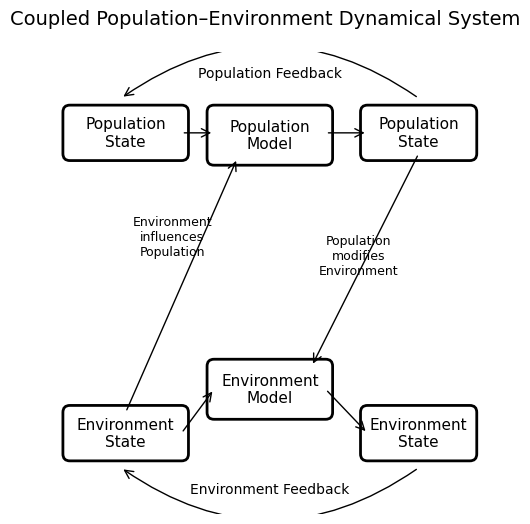

In [13]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# --------------------------------------------------
# Figure
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(6, 6))

ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis("off")

# --------------------------------------------------
# Helper function
# --------------------------------------------------

def add_box(x, y, w, h, text, fontsize=11):
    box = FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle="round,pad=0.15",
        linewidth=2,
        fill=False
    )

    ax.add_patch(box)

    ax.text(
        x + w/2,
        y + h/2,
        text,
        ha="center",
        va="center",
        fontsize=fontsize
    )

# --------------------------------------------------
# Nodes
# --------------------------------------------------

add_box(0.8, 7.8, 2.4, 0.9, "Population\nState")

add_box(3.9, 7.7, 2.4, 1.0, "Population\nModel")

add_box(7.2, 7.8, 2.2, 0.9, "Population\nState")

add_box(3.9, 2.2, 2.4, 1.0, "Environment\nModel")

add_box(0.8, 1.3, 2.4, 0.9, "Environment\nState")

add_box(7.2, 1.3, 2.2, 0.9, "Environment\nState")

# --------------------------------------------------
# Population update
# --------------------------------------------------

ax.add_patch(FancyArrowPatch(
    (3.2,8.25),
    (3.9,8.25),
    arrowstyle="->",
    mutation_scale=15
))

ax.add_patch(FancyArrowPatch(
    (6.3,8.25),
    (7.2,8.25),
    arrowstyle="->",
    mutation_scale=15
))

# --------------------------------------------------
# Environment input to Population Model
# --------------------------------------------------

ax.add_patch(FancyArrowPatch(
    (2.0,2.2),
    (4.4,7.7),
    arrowstyle="->",
    mutation_scale=15
))

# --------------------------------------------------
# Population influences Environment Model
# --------------------------------------------------

ax.add_patch(FancyArrowPatch(
    (8.3,7.8),
    (6.0,3.2),
    arrowstyle="->",
    mutation_scale=15
))

# --------------------------------------------------
# Environment update
# --------------------------------------------------

ax.add_patch(FancyArrowPatch(
    (3.2,1.75),
    (3.9,2.7),
    arrowstyle="->",
    mutation_scale=15
))

ax.add_patch(FancyArrowPatch(
    (6.3,2.7),
    (7.2,1.75),
    arrowstyle="->",
    mutation_scale=15
))

# --------------------------------------------------
# Population feedback
# --------------------------------------------------

ax.add_patch(FancyArrowPatch(
    (8.3,9.0),
    (1.9,9.0),
    connectionstyle="arc3,rad=0.35",
    arrowstyle="->",
    mutation_scale=15
))

ax.text(
    5.1,
    9.45,
    "Population Feedback",
    ha="center",
    fontsize=10
)

# --------------------------------------------------
# Environment feedback
# --------------------------------------------------

ax.add_patch(FancyArrowPatch(
    (8.3,1.0),
    (1.9,1.0),
    connectionstyle="arc3,rad=-0.35",
    arrowstyle="->",
    mutation_scale=15
))

ax.text(
    5.1,
    0.45,
    "Environment Feedback",
    ha="center",
    fontsize=10
)

# --------------------------------------------------
# Labels describing cross coupling
# --------------------------------------------------

ax.text(
    3.0,
    5.6,
    "Environment\ninfluences\nPopulation",
    fontsize=9,
    ha="center"
)

ax.text(
    7.0,
    5.2,
    "Population\nmodifies\nEnvironment",
    fontsize=9,
    ha="center"
)

# --------------------------------------------------
# Title
# --------------------------------------------------

ax.set_title(
    "Coupled Population–Environment Dynamical System",
    fontsize=14,
    pad=20
)

plt.show()


The population model computes the rate of change of the population using both the current population and the current environmental conditions. The resulting population then influences the environmental model, which updates the environmental variables through ecological processes such as resource consumption, nutrient cycling, habitat modification, or waste production.

The updated environment is then fed back into the population model during the next time step, forming a continuous feedback loop.

This viewpoint is characteristic of **systems theory**, in which multiple interacting subsystems evolve simultaneously through coupled differential equations rather than independently.

## 3. Model 1 — A Single Population in an Abiotic Environment

We begin with the simplest possible ecological system consisting of a single population interacting with its abiotic environment.

Let

$$
P(t)
$$

represent the population size as a function of time.

The environment is described by a collection of environmental variables,

$$
T(t),\;
W(t),\;
N(t),\;
L(t),\;
O(t),\;
S(t),\;
H(t),\;
\ldots
$$

where, for example,

- $T$ represents temperature,
- $W$ represents water availability,
- $N$ represents nutrient availability,
- $L$ represents light intensity,
- $O$ represents oxygen concentration,
- $S$ represents salinity,
- $H$ represents pH,

while the ellipsis indicates that additional environmental variables may be introduced whenever appropriate.

Rather than assuming population growth depends upon only one variable, we instead assume that every environmental quantity may influence the rate at which the population changes.

### 3.1 Population Growth Equation

Ignoring feedback for the moment, the rate of change of the population may be expressed as

$$
\boxed{
\frac{dP}{dt}
=
rP
+
\frac{\partial P}{\partial T}\frac{dT}{dt}
+
\frac{\partial P}{\partial W}\frac{dW}{dt}
+
\frac{\partial P}{\partial N}\frac{dN}{dt}
+
\frac{\partial P}{\partial L}\frac{dL}{dt}
+
\frac{\partial P}{\partial O}\frac{dO}{dt}
+
\cdots
}
$$

where

- $rP$ represents the intrinsic population growth,
- each partial derivative measures the sensitivity of the population to a particular environmental variable,
- each environmental variable is itself allowed to vary through time.

This expression is simply an application of the multivariable chain rule. It states that population growth is influenced not only by the current environmental conditions, but also by the rates at which those conditions themselves are changing.

### 3.2 Environmental Feedback

The previous equation assumes that environmental variables change independently of the population. In reality, however, populations frequently modify their environment.

For example,

- plant populations consume nutrients,
- herbivores reduce vegetation,
- forests alter soil moisture,
- algae modify dissolved oxygen,
- microorganisms influence soil chemistry.

Consequently, each environmental variable may itself depend upon the population.

In general,

$$
\frac{dE_i}{dt}
=
G_i(P)
$$

where $E_i$ represents any environmental variable and $G_i$ is an arbitrary function describing how the population influences that variable. Possibly other variables may affect it as well.

Examples include

$$
\frac{dN}{dt}=G_N(P)
$$

$$
\frac{dW}{dt}=G_W(P)
$$

$$
\frac{dO}{dt}=G_O(P)
$$

and similarly for any additional environmental variables.

The population and environment therefore become **coupled differential equations**, meaning that neither system evolves independently of the other.

## 3.3 Feedback Representation

The mathematical equations introduced in the previous sections naturally form a coupled feedback system.

The population equation depends upon both the current population and the current environment,

$$
\frac{dP}{dt}=F(P,E),
$$

while the environmental equations depend upon both the current environment and the population,

$$
\frac{dE}{dt}=G(P,E).
$$

These relationships may be summarized by the following coupled feedback system.

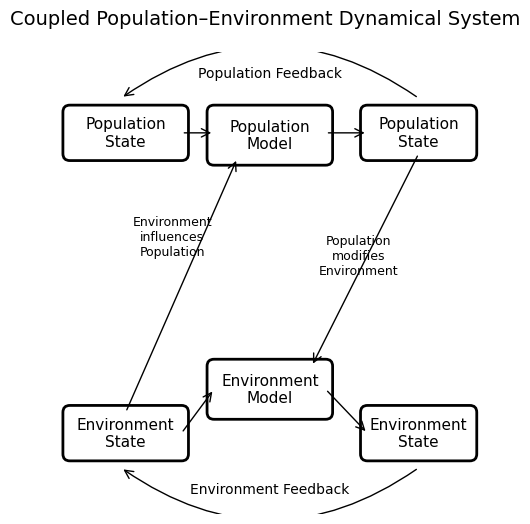

In [14]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# --------------------------------------------------
# Figure
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(6, 6))

ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis("off")

# --------------------------------------------------
# Helper function
# --------------------------------------------------

def add_box(x, y, w, h, text, fontsize=11):
    box = FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle="round,pad=0.15",
        linewidth=2,
        fill=False
    )

    ax.add_patch(box)

    ax.text(
        x + w/2,
        y + h/2,
        text,
        ha="center",
        va="center",
        fontsize=fontsize
    )

# --------------------------------------------------
# Nodes
# --------------------------------------------------

add_box(0.8, 7.8, 2.4, 0.9, "Population\nState")

add_box(3.9, 7.7, 2.4, 1.0, "Population\nModel")

add_box(7.2, 7.8, 2.2, 0.9, "Population\nState")

add_box(3.9, 2.2, 2.4, 1.0, "Environment\nModel")

add_box(0.8, 1.3, 2.4, 0.9, "Environment\nState")

add_box(7.2, 1.3, 2.2, 0.9, "Environment\nState")

# --------------------------------------------------
# Population update
# --------------------------------------------------

ax.add_patch(FancyArrowPatch(
    (3.2,8.25),
    (3.9,8.25),
    arrowstyle="->",
    mutation_scale=15
))

ax.add_patch(FancyArrowPatch(
    (6.3,8.25),
    (7.2,8.25),
    arrowstyle="->",
    mutation_scale=15
))

# --------------------------------------------------
# Environment input to Population Model
# --------------------------------------------------

ax.add_patch(FancyArrowPatch(
    (2.0,2.2),
    (4.4,7.7),
    arrowstyle="->",
    mutation_scale=15
))

# --------------------------------------------------
# Population influences Environment Model
# --------------------------------------------------

ax.add_patch(FancyArrowPatch(
    (8.3,7.8),
    (6.0,3.2),
    arrowstyle="->",
    mutation_scale=15
))

# --------------------------------------------------
# Environment update
# --------------------------------------------------

ax.add_patch(FancyArrowPatch(
    (3.2,1.75),
    (3.9,2.7),
    arrowstyle="->",
    mutation_scale=15
))

ax.add_patch(FancyArrowPatch(
    (6.3,2.7),
    (7.2,1.75),
    arrowstyle="->",
    mutation_scale=15
))

# --------------------------------------------------
# Population feedback
# --------------------------------------------------

ax.add_patch(FancyArrowPatch(
    (8.3,9.0),
    (1.9,9.0),
    connectionstyle="arc3,rad=0.35",
    arrowstyle="->",
    mutation_scale=15
))

ax.text(
    5.1,
    9.45,
    "Population Feedback",
    ha="center",
    fontsize=10
)

# --------------------------------------------------
# Environment feedback
# --------------------------------------------------

ax.add_patch(FancyArrowPatch(
    (8.3,1.0),
    (1.9,1.0),
    connectionstyle="arc3,rad=-0.35",
    arrowstyle="->",
    mutation_scale=15
))

ax.text(
    5.1,
    0.45,
    "Environment Feedback",
    ha="center",
    fontsize=10
)

# --------------------------------------------------
# Labels describing cross coupling
# --------------------------------------------------

ax.text(
    3.0,
    5.6,
    "Environment\ninfluences\nPopulation",
    fontsize=9,
    ha="center"
)

ax.text(
    7.0,
    5.2,
    "Population\nmodifies\nEnvironment",
    fontsize=9,
    ha="center"
)

# --------------------------------------------------
# Title
# --------------------------------------------------

ax.set_title(
    "Coupled Population–Environment Dynamical System",
    fontsize=14,
    pad=20
)

plt.show()

Although simplified, this diagram illustrates the essential structure of the system.

The population model uses the current environmental conditions to compute the population dynamics.

The environment model uses the resulting population to compute changes in the surrounding environment.

The updated environment is then supplied back to the population model, completing the feedback loop.

Unlike a simple cause-and-effect chain, neither subsystem is independent. Each continuously influences the other, forming a **coupled dynamical system** whose future behavior emerges from the interaction of both equations.

## 4. Model 2 — Two Interacting Populations

The previous model considered a single population interacting with a changing abiotic environment. Ecological communities, however, are rarely composed of only one population. Organisms coexist with other species, and these interactions may influence population growth, decline, and stability.

To extend the framework, we now introduce a second population.

Let

$$
P_A(t)
$$

represent the size of Population A and

$$
P_B(t)
$$

represent the size of Population B.

These two populations may represent any pair of interacting species, including:

- competing species,
- predator and prey,
- parasite and host,
- mutualistic partners,
- or any other ecological relationship.

The objective is not to define a specific interaction model, but rather to create a general mathematical framework where different ecological mechanisms can be represented by including or removing variables from the population dynamics equations.

### 4.1 General Population Function

For a single population, we previously represented population change as a function of itself and the surrounding environment.

For two populations, Population A can be described by the general function

$$
\boxed{
\frac{dP_A}{dt}
=
F_A(P_A,P_B,E)
}
$$

where

- $P_A$ represents the current state of Population A,
- $P_B$ represents the current state of Population B,
- $E$ represents the collection of environmental variables,
- $F_A$ represents the complete set of processes determining the rate of change of Population A.

Similarly, Population B follows

$$
\boxed{
\frac{dP_B}{dt}
=
F_B(P_B,P_A,E)
}
$$

The important concept is that $F_A$ and $F_B$ are not single equations describing one mechanism. Instead, they are general functions containing every variable necessary to describe the dynamics of each population.

The variables included inside these functions depend on the ecological system being studied.

### 4.2 Expanding the Population Function

The function

$$
F_A(P_A,P_B,E)
$$

can be expanded into its individual components.

For example, the rate of change of Population A may depend on:

- intrinsic population growth,
- environmental variables,
- interactions with Population B,
- and any additional ecological processes.

A more explicit representation is

$$
\boxed{
\frac{dP_A}{dt}
=
r_A P_A
+
F_A(T,W,N,L,O,S,H,\ldots)
+
F_A(P_B)
}
$$

where environmental variables may include

$$
E=
(T,W,N,L,O,S,H,\ldots)
$$

with:

- $T$ = temperature,
- $W$ = water availability,
- $N$ = nutrient availability,
- $L$ = light availability,
- $O$ = oxygen concentration,
- $S$ = salinity,
- $H$ = pH.

The ellipsis indicates that additional environmental variables may be introduced whenever necessary.

Importantly, the variables themselves do not need to remain at this level of abstraction.

For example, nutrient availability is not a single ecological quantity. It may be decomposed into individual nutrients:

$$
N=
(N_{nitrogen},
N_{phosphorus},
N_{potassium},
\ldots)
$$

Similarly, water availability may include:

$$
W=
(W_{soil},
W_{surface},
W_{groundwater},
\ldots)
$$

The framework allows any variable to be expanded into additional variables when the ecological mechanism requires greater detail.

### 4.3 Population Interactions as Composite Variables

The same principle applies to population interactions.

The variable

$$
P_B
$$

inside the function

$$
F_A(P_A,P_B,E)
$$

does not necessarily represent a single mechanism.

Population B may influence Population A through multiple pathways, including:

- competition,
- predation,
- disease transmission,
- habitat modification,
- resource consumption,
- chemical signaling,
- or other biological processes.

Therefore, the interaction term may itself be expanded.

Conceptually,

$$
P_B
\rightarrow
\begin{bmatrix}
\text{resource competition}\\
\text{predation pressure}\\
\text{disease transmission}\\
\text{habitat modification}\\
\vdots
\end{bmatrix}
$$

The apparent interaction between two populations may therefore contain many underlying mechanisms.

The purpose of the general function is not to hide these mechanisms permanently, but to provide a framework where additional variables can be introduced whenever they represent independent processes.

### 4.4 Direct and Indirect Interactions

A central challenge in constructing ecological models is determining which variables should be included as independent terms.

Two populations may appear to interact directly, but the relationship may actually occur through an intermediate environmental variable.

For example, suppose two plant populations compete because they both consume nitrogen.

The causal pathway is

$$
P_B
\rightarrow
N
\rightarrow
P_A
$$

Population B changes nitrogen availability, and nitrogen availability influences Population A.

In this case, the influence of Population B on Population A is already represented through the environmental subsystem.

Adding an additional direct term

$$
\frac{\partial F_A}{\partial P_B}
$$

would duplicate information already contained in the environmental equations.

Therefore, the interaction should be represented through the intermediate variable rather than as a separate population-population relationship.

### 4.5 Chain Rule and Removal of Redundant Interactions

The chain rule provides a mathematical way to determine whether a population interaction represents an independent mechanism or whether it is already explained through intermediate variables.

Consider a model where Population A appears to depend on Population B and nitrogen availability:

$$
\frac{dP_A}{dt}
=
F_A(P_A,P_B,N)
$$

At first, this suggests that Population B has a direct influence on Population A.

However, suppose the ecological mechanism is:

$$
P_B
\rightarrow
N
\rightarrow
P_A
$$

where Population B influences Population A only by changing nitrogen availability.

In this case, Population B is not an independent variable in the Population A equation.

Instead, the system should be separated into two coupled equations:

$$
\frac{dP_A}{dt}
=
F_A(P_A,N)
$$

and

$$
\frac{dN}{dt}
=
G_N(N,P_B)
$$

The influence of Population B on Population A still exists, but it occurs through the environmental variable nitrogen.

The total effect of Population B on Population A can be described using the chain rule:

$$
\boxed{
\frac{\partial F_A}{\partial P_B}
=
\frac{\partial F_A}{\partial N}
\frac{\partial N}{\partial P_B}
}
$$

This equation states that the effect of Population B on Population A is composed of two separate processes:

1. Population B changes nitrogen availability:

$$
\frac{\partial N}{\partial P_B}
$$

2. Nitrogen availability changes Population A:

$$
\frac{\partial F_A}{\partial N}
$$

Because these two relationships are already represented explicitly in the coupled system, adding an additional direct interaction term

$$
\frac{\partial F_A}{\partial P_B}
$$

would duplicate the same ecological mechanism.

Therefore, the modeling rule is:

**If the influence of one variable on another can be completely explained through intermediate variables already present in the system, the direct interaction term should be removed and replaced by the underlying causal pathway.**

This prevents double-counting and produces a model where each term represents an independent ecological mechanism.

### 4.6 Independent Biological Interactions

Some interactions cannot be reduced into environmental pathways.

Predator-prey relationships provide a clear example.

A predator directly consumes prey. The influence of the predator population on prey mortality cannot be completely explained by changes in temperature, water availability, or nutrient availability.

Therefore, the interaction remains an independent component of the population function.

The relationship may be represented as

$$
\frac{\partial F_A}{\partial P_B}
\neq 0
$$

and

$$
\frac{\partial F_B}{\partial P_A}
\neq 0
$$

where both populations directly influence one another.

Other examples of independent biological interactions include:

- parasitism,
- disease transmission,
- mating interactions,
- territorial competition,
- direct mutualism,
- facilitation.

The distinction between direct and indirect interactions provides a method for deciding which variables belong explicitly within a population dynamics model.

### 4.7 Transition to Community Models

The two-population model demonstrates the basic principle that population dynamics functions may contain any combination of:

- intrinsic population variables,
- environmental variables,
- and independent biological interactions.

The next logical extension is to replace the two populations with an arbitrary number of populations:

$$
P_1,P_2,\ldots,P_n
$$

and an arbitrary number of environmental variables:

$$
E_1,E_2,\ldots,E_m
$$

creating a general community-level dynamical system.

The same rules apply:

- variables may be expanded into additional dependent variables,
- indirect interactions may be removed through the chain rule,
- only independent mechanisms require separate terms.

This provides the foundation for constructing a general mathematical representation of ecological communities.

### 4.8 Expanded Differential Representation

The function notation introduced previously provides a compact representation of population dynamics:

$$
\frac{dP_A}{dt}=F_A(P_A,P_B,E)
$$

However, the same relationship may also be expanded into individual components to show the contribution of each mechanism.

For Population A:

$$
\boxed{
\frac{dP_A}{dt}
=
r_AP_A
+
\sum_i
\frac{\partial F_A}{\partial E_i}
\frac{dE_i}{dt}
+
\frac{\partial F_A}{\partial P_B}
\frac{dP_B}{dt}
}
$$

Likewise, for Population B:

$$
\boxed{
\frac{dP_B}{dt}
=
r_BP_B
+
\sum_i
\frac{\partial F_B}{\partial E_i}
\frac{dE_i}{dt}
+
\frac{\partial F_B}{\partial P_A}
\frac{dP_A}{dt}
}
$$

The first term represents intrinsic population growth.

The second term represents the influence of environmental variables, where each environmental variable contributes according to:

$$
\frac{\partial F_A}{\partial E_i}
\frac{dE_i}{dt}
$$

For example, environmental variables may include:

$$
E_i=
(T,W,N,L,O,\ldots)
$$

representing temperature, water availability, nutrients, light, oxygen, and other abiotic factors.

The final term represents direct biological interaction between the populations.

This term is only included when Population B has an independent influence on Population A that cannot already be explained through environmental variables or other intermediate mechanisms.

The two-population model therefore provides the smallest example of a general ecological interaction network.

By extending the same principles to additional populations, environmental variables, and interaction pathways, the framework can be generalized into a model describing entire ecological communities.

## 5. Model 3 — Community Ecology: Generalizing to Multiple Populations

The previous models increased complexity step by step.

Model 1 considered a single population interacting with a changing environment.

Model 2 introduced a second population and demonstrated how direct and indirect interactions can be separated using dependency relationships and the chain rule.

The next step is to generalize the framework to an ecological community containing many interacting populations.

Let the community contain:

$$
P_1,P_2,\ldots,P_n
$$

populations and

$$
E_1,E_2,\ldots,E_m
$$

environmental variables.

The goal is not to explicitly define every possible ecological mechanism, but rather to construct a mathematical framework where any relevant mechanism can be added as an independent variable or interaction term.

### 5.1 Generalization to n Populations

The previous model considered two interacting populations:

$$
P_A
$$

and

$$
P_B.
$$

However, real ecological communities contain many populations interacting simultaneously with one another and with their shared environment.

To generalize the model, we define a community containing:

$$
P_1,P_2,\ldots,P_n
$$

where each $P_i$ represents the state of an individual population within the community.

Likewise, the environment can be represented as a collection of variables:

$$
E_1,E_2,\ldots,E_m
$$

where each $E_k$ represents an abiotic or environmental factor.

For example:

$$
E_k=
(T,W,N,L,O,pH,\ldots)
$$

may represent temperature, water availability, nutrients, light availability, oxygen concentration, pH, and any additional environmental variables required by the system.

The complete state of the ecological system can therefore be represented as the combination of all populations and environmental variables:

$$
(P_1,P_2,\ldots,P_n,E_1,E_2,\ldots,E_m)
$$

For any population $P_i$, the general population dynamics equation becomes:

$$
\boxed{
\frac{dP_i}{dt}
=
F_i
(
P_1,P_2,\ldots,P_n,
E_1,E_2,\ldots,E_m
)
}
$$

where $F_i$ represents the complete set of ecological processes determining the rate of change of population $i$.

This formulation allows each population to depend on:

- itself,
- other populations,
- environmental conditions,
- and any additional variables necessary to describe the ecological system.

Importantly, not every possible variable must appear in every equation.

For example, a deep-sea organism may depend strongly on oxygen concentration and pressure but not directly on sunlight, while a terrestrial plant may depend strongly on light availability but not salinity.

The structure of each function is determined by the ecological mechanisms present in the system being modeled.



## 5.2 Expanded Community Dynamics Equation

The general function representation

$$
\frac{dP_i}{dt}
=
F_i(P_1,P_2,\ldots,P_n,E_1,E_2,\ldots,E_m)
$$

describes the complete dynamics of population $i$, but it does not explicitly show the individual mechanisms contributing to population change.

The function can be expanded into separate components:

$$
\boxed{
\frac{dP_i}{dt}
=
r_iP_i
+
\sum_{k=1}^{m}
\frac{\partial F_i}{\partial E_k}
\frac{dE_k}{dt}
+
\sum_{j=1}^{n}
I_{ij}
}
$$

where:

- $r_iP_i$ represents intrinsic population growth,
- the environmental summation represents the combined influence of abiotic variables,
- the interaction summation represents independent biological interactions.

The environmental contribution is represented as:

$$
\sum_{k=1}^{m}
\frac{\partial F_i}{\partial E_k}
\frac{dE_k}{dt}
$$

where each environmental variable contributes according to both:

1. how strongly the population responds to that variable,

$$
\frac{\partial F_i}{\partial E_k}
$$

and

2. how quickly that environmental variable is changing,

$$
\frac{dE_k}{dt}.
$$

Similarly, biological interactions are represented by:

$$
\sum_{j=1}^{n}I_{ij}
$$

where $I_{ij}$ represents only independent direct interactions between populations.

The purpose of separating these terms is not to create a fixed universal equation for all ecosystems, but rather to provide a framework where different ecological mechanisms can be added, removed, or expanded depending on the system being studied.

For example, a forest ecosystem may require detailed plant competition and nutrient cycling terms, while an ocean ecosystem may require terms describing predation, temperature, and dissolved oxygen.

The equation therefore represents a general template rather than a single ecological model.

### 5.3 Generalized Community Model

The generalized community model therefore follows the same principles established in the previous sections:

1. Every population is represented by a rate-of-change equation.

$$
\frac{dP_i}{dt}
$$

2. Environmental variables influence population dynamics.

$$
E_1,E_2,\ldots,E_m
$$

3. Populations may influence one another through independent biological mechanisms.

$$
I_{ij}
$$

4. Variables may be expanded into additional variables when greater biological detail is required.

For example:

$$
N
\rightarrow
(N_{nitrogen},N_{phosphorus},N_{potassium},\ldots)
$$

or

$$
P_j
\rightarrow
(\text{competition},\text{predation},\text{disease},\ldots)
$$

5. Redundant interactions are removed when they can be represented through existing dependencies.

The result is a flexible mathematical framework capable of describing ecological systems ranging from simple two-species interactions to complex biological communities.

### 5.4 Matrix Representation and Computational Modeling

As the number of populations and environmental variables increases, writing individual equations becomes impractical.

A community containing hundreds or thousands of populations may require a system containing thousands or millions of possible interactions.

To represent such systems computationally, populations can be stored as vectors.

The population state can be represented as:

$$
\mathbf{P}
=
\begin{bmatrix}
P_1\\
P_2\\
\vdots\\
P_n
\end{bmatrix}
$$

and environmental variables can be represented as:

$$
\mathbf{E}
=
\begin{bmatrix}
E_1\\
E_2\\
\vdots\\
E_m
\end{bmatrix}
$$

The complete ecological system can then be written more compactly as:

$$
\boxed{
\frac{d\mathbf{P}}{dt}
=
\mathbf{F}(\mathbf{P},\mathbf{E})
}
$$

This notation does not change the underlying model. It simply provides a more efficient way to store and manipulate many equations simultaneously.

In computer models, the components of these vectors and matrices can be populated using:

- field measurements,
- ecological surveys,
- climate databases,
- remote sensing data,
- laboratory experiments,
- or parameter estimates from previous research.

For example, an interaction matrix may store the strength and direction of relationships between populations:

$$
\mathbf{I}
=
\begin{bmatrix}
I_{11}&I_{12}&\cdots&I_{1n}\\
I_{21}&I_{22}&\cdots&I_{2n}\\
\vdots&\vdots&\ddots&\vdots\\
I_{n1}&I_{n2}&\cdots&I_{nn}
\end{bmatrix}
$$

where each element describes an interaction between two populations.

The purpose of this representation is not simply mathematical elegance. Matrix-based models allow ecological systems to be stored, analyzed, simulated, and updated computationally.

As ecological datasets become larger, this type of representation becomes increasingly important for building models capable of studying complex communities.

### 5.5 Jacobian Matrix and Ecological Sensitivity

The vector representation introduced in the previous section provides a compact way to write a community model:

$$
\frac{d\mathbf{P}}{dt}
=
\mathbf{F}(\mathbf{P},\mathbf{E})
$$

However, another important question can be asked:

**How does a small change in one population affect the rate of change of every other population?**

To describe these relationships mathematically, we can examine the partial derivatives of each population equation with respect to each population variable.

This produces the Jacobian matrix.

The Jacobian is defined as:

$$
\boxed{
J_{ij}
=
\frac{\partial F_i}{\partial P_j}
}
$$

where:

- $F_i$ represents the population dynamics equation for population $i$,
- $P_j$ represents another population within the community,
- $J_{ij}$ represents how strongly population $j$ influences the rate of change of population $i$.

For a community containing $n$ populations, the Jacobian takes the form:

$$
\mathbf{J}
=
\begin{bmatrix}
\frac{\partial F_1}{\partial P_1}
&
\frac{\partial F_1}{\partial P_2}
&
\cdots
&
\frac{\partial F_1}{\partial P_n}
\\
\frac{\partial F_2}{\partial P_1}
&
\frac{\partial F_2}{\partial P_2}
&
\cdots
&
\frac{\partial F_2}{\partial P_n}
\\
\vdots
&
\vdots
&
\ddots
&
\vdots
\\
\frac{\partial F_n}{\partial P_1}
&
\frac{\partial F_n}{\partial P_2}
&
\cdots
&
\frac{\partial F_n}{\partial P_n}
\end{bmatrix}
$$

Each element represents one possible influence pathway between two populations.

For example:

$$
J_{12}
=
\frac{\partial F_1}{\partial P_2}
$$

describes how changes in Population 2 affect the growth rate of Population 1.

A positive value may indicate a beneficial interaction, while a negative value may indicate a harmful interaction such as predation or competition.

A value near zero indicates that the interaction is weak or nonexistent.



---

The Jacobian also provides a mathematical way to represent the dependency rules discussed earlier.

Not every possible interaction should automatically appear as a non-zero term.

For example, if Population 2 influences Population 1 only through nutrient availability:

$$
P_2
\rightarrow
N
\rightarrow
P_1
$$

then the direct term:

$$
\frac{\partial F_1}{\partial P_2}
$$

may be unnecessary because the relationship is already represented through:

$$
\frac{\partial F_1}{\partial N}
\frac{\partial N}{\partial P_2}
$$

Therefore, many ecological Jacobian matrices are sparse, meaning that most possible interactions are zero.

This sparsity is important computationally because it allows large ecological systems to be modeled efficiently without requiring every possible species interaction to be explicitly defined.

---

The Jacobian also provides information about ecological stability.

Near an equilibrium point, the Jacobian describes how small disturbances propagate through the system.

For example:

- a population increase may create negative feedback and return the system toward equilibrium,
- a population decrease may trigger cascading effects,
- a positive feedback loop may amplify disturbances.

Therefore, the Jacobian acts as a mathematical representation of the structure of ecological interactions.

In computational ecology, these matrices allow researchers to study:

- community stability,
- resilience to disturbance,
- species removal effects,
- invasive species impacts,
- and ecosystem responses to environmental change.

The purpose of introducing the Jacobian is not to replace ecological understanding with mathematics, but to provide a formal language for describing how complex communities respond to change.

### 5.6 Matrix Representation of Community Dynamics

The expanded community equation:

$$
\frac{dP_i}{dt}
=
r_iP_i
+
\sum_{k=1}^{m}
\frac{\partial F_i}{\partial E_k}
\frac{dE_k}{dt}
+
\sum_{j=1}^{n}
I_{ij}
$$

can be rewritten in matrix form.

The population state is represented as a vector:

$$
\mathbf{P}
=
\begin{bmatrix}
P_1\\
P_2\\
\vdots\\
P_n
\end{bmatrix}
$$

and the environmental state as:

$$
\mathbf{E}
=
\begin{bmatrix}
E_1\\
E_2\\
\vdots\\
E_m
\end{bmatrix}
$$

The population-environment relationships are represented by an environmental Jacobian:

$$
\mathbf{J}_{PE}
=
\frac{\partial \mathbf{F}}{\partial \mathbf{E}}
$$

where each element describes how a population responds to an environmental variable:

$$
(\mathbf{J}_{PE})_{ik}
=
\frac{\partial F_i}{\partial E_k}
$$

The environmental change vector is:

$$
\frac{d\mathbf{E}}{dt}
=
\begin{bmatrix}
\frac{dE_1}{dt}\\
\frac{dE_2}{dt}\\
\vdots\\
\frac{dE_m}{dt}
\end{bmatrix}
$$

The independent population interactions are represented by the interaction Jacobian:

$$
\mathbf{J}_{PP}
=
\frac{\partial \mathbf{F}}{\partial \mathbf{P}}
$$

where:

$$
(\mathbf{J}_{PP})_{ij}
=
\frac{\partial F_i}{\partial P_j}
$$

After removing interactions that are already explained through intermediate environmental pathways, the remaining non-zero elements of this matrix represent the independent interaction terms:

$$
\mathbf{I}
\subseteq
\mathbf{J}_{PP}
$$

The complete community equation can therefore be written as:

$$
\boxed{
\frac{d\mathbf{P}}{dt}
=
\mathbf{R}\mathbf{P}
+
\mathbf{J}_{PE}
\frac{d\mathbf{E}}{dt}
+
\mathbf{I}\mathbf{P}
}
$$

where:

- $\mathbf{R}\mathbf{P}$ represents intrinsic population growth,
- $\mathbf{J}_{PE}\frac{d\mathbf{E}}{dt}$ represents environmental effects,
- $\mathbf{I}\mathbf{P}$ represents independent direct population interactions.

This matrix form provides a computational representation of the same ecological model, allowing populations, environmental variables, and interaction strengths to be stored and analyzed as structured data.

---

The matrix multiplication notation represents the same summations written earlier.

For example, the environmental contribution:

$$
\mathbf{J}_{PE}
\frac{d\mathbf{E}}{dt}
$$

expands conceptually as:

$$
\begin{bmatrix}
\frac{\partial F_1}{\partial E_1} &
\frac{\partial F_1}{\partial E_2} &
\cdots &
\frac{\partial F_1}{\partial E_m}
\\
\frac{\partial F_2}{\partial E_1} &
\frac{\partial F_2}{\partial E_2} &
\cdots &
\frac{\partial F_2}{\partial E_m}
\\
\vdots &
\vdots &
\ddots &
\vdots
\\
\frac{\partial F_n}{\partial E_1} &
\frac{\partial F_n}{\partial E_2} &
\cdots &
\frac{\partial F_n}{\partial E_m}
\end{bmatrix}
\begin{bmatrix}
\frac{dE_1}{dt}\\
\frac{dE_2}{dt}\\
\vdots\\
\frac{dE_m}{dt}
\end{bmatrix}
$$

which produces the summed environmental effects for each population.

Likewise, the interaction term:

$$
\mathbf{I}\mathbf{P}
$$

represents:

$$
\begin{bmatrix}
I_{11}&I_{12}&\cdots&I_{1n}\\
I_{21}&I_{22}&\cdots&I_{2n}\\
\vdots&\vdots&\ddots&\vdots\\
I_{n1}&I_{n2}&\cdots&I_{nn}
\end{bmatrix}
\begin{bmatrix}
P_1\\
P_2\\
\vdots\\
P_n
\end{bmatrix}
$$

where each row represents the combined influence of all other populations on the rate of change of one population.

The matrix notation therefore provides a compact representation of the same summation rules used throughout the model.